In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(os.path.join(dirname))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/global-wheat-detection
/kaggle/input/competitions/global-wheat-detection/test
/kaggle/input/competitions/global-wheat-detection/train


In [9]:
import ast
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [10]:
# 경로 설정
INPUT_IMG_DIR = '/kaggle/input/competitions/global-wheat-detection/train'
WORKING_DIR = '/kaggle/working/wheat'

In [11]:
# 폴더 구조 생성
for phase in ['train', 'val']:
    os.makedirs(f'{WORKING_DIR}/images/{phase}', exist_ok=True)
    os.makedirs(f'{WORKING_DIR}/labels/{phase}', exist_ok=True)

# 데이터 로드 및 분리
train_df = pd.read_csv('/kaggle/input/competitions/global-wheat-detection/train.csv')
train_df['bbox'] = train_df['bbox'].apply(ast.literal_eval)

all_image_ids = train_df['image_id'].unique()
train_ids, val_ids = train_test_split(all_image_ids, test_size=0.2, random_state=42)

In [12]:
# YOLO 좌표 변환 함수
def convert_to_yolo(size, box):
    dw, dh = 1./size[0], 1./size[1]
    x_center = box[0] + box[2] / 2.0
    y_center = box[1] + box[3] / 2.0
    return (x_center * dw, y_center * dh, box[2] * dw, box[3] * dh)

# 심볼릭 링크 생성(kaggle 구조 때문) + TXT 저장
def prepare_yolo_data(image_ids, phase):
    for img_id in tqdm(image_ids, desc=f"Preparing {phase}"):
        # 이미지 심볼릭 링크 걸기
        src_img = os.path.join(INPUT_IMG_DIR, f'{img_id}.jpg')
        dst_img = os.path.join(WORKING_DIR, 'images', phase, f'{img_id}.jpg')
        if not os.path.exists(dst_img):
            os.symlink(src_img, dst_img)
            
        # 해당 이미지의 모든 박스 가져와서 TXT로 저장
        img_bboxes = train_df[train_df['image_id'] == img_id]['bbox'].values
        label_path = os.path.join(WORKING_DIR, 'labels', phase, f'{img_id}.txt')
        
        with open(label_path, 'w') as f:
            for box in img_bboxes:
                yolo_box = convert_to_yolo((1024, 1024), box)
                f.write(f"0 {yolo_box[0]:.6f} {yolo_box[1]:.6f} {yolo_box[2]:.6f} {yolo_box[3]:.6f}\n")

# 5. 실행
prepare_yolo_data(train_ids, 'train')
prepare_yolo_data(val_ids, 'val')

print(f"\n✅ 준비 완료! 경로: {WORKING_DIR}")

Preparing val: 100%|██████████| 675/675 [00:08<00:00, 80.68it/s]


✅ 준비 완료! 경로: /kaggle/working/wheat


In [13]:
import yaml

data_yaml = {
    'path': '/kaggle/working/wheat',
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['wheat']
}

with open('/kaggle/working/wheat_data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

In [14]:
# !pip install ultralytics -q

In [15]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt') 

results = model.train(
    data='/kaggle/working/wheat_data.yaml',
    epochs=10,                             
    imgsz=1024,                            
    batch=8,                               
    project='wheat_study',                 
    name='baseline_run',       
    exist_ok=True,
    device=0,                              
)

Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/wheat_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_run-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

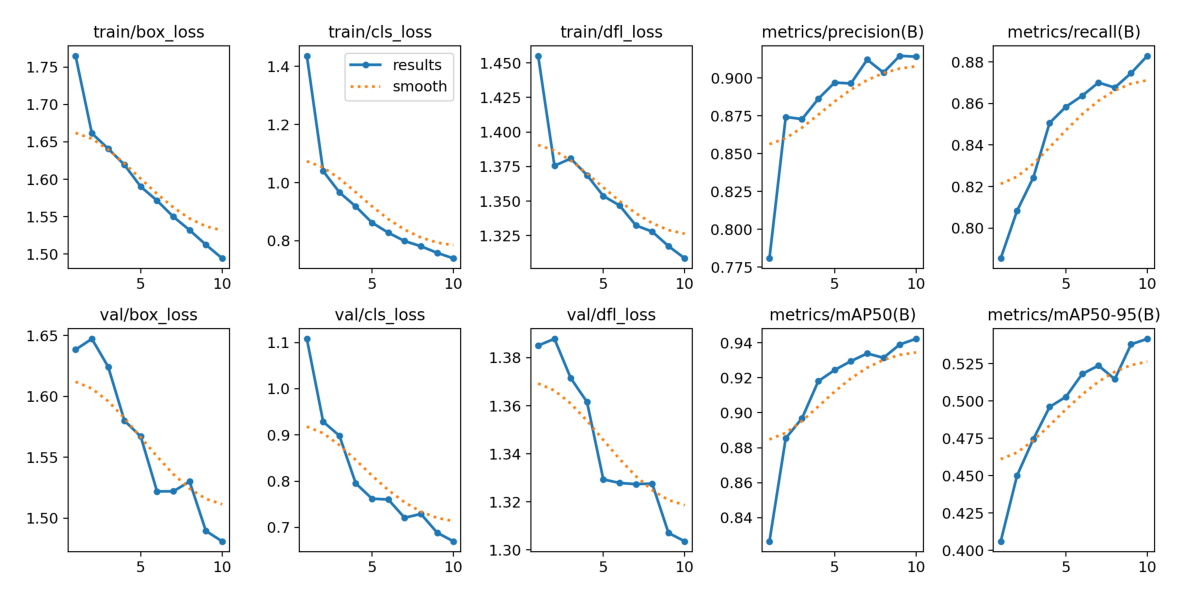

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 학습 결과 그래프 (Loss, mAP 등) 출력
result_path = '/kaggle/working/runs/detect/wheat_study/baseline_run-2/results.png'
if os.path.exists(result_path):
    img = cv2.imread(result_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [19]:
# 학습된 베스트 모델로 검증 수행
metrics = model.val()

# 주요 정확도 지표 출력
print(f"mAP50: {metrics.box.map50:.4f}")      # IoU 0.5 기준 정확도 (보통 이걸 많이 봐요)
print(f"mAP50-95: {metrics.box.map:.4f}")     # 더 엄격한 기준의 평균 정확도
print(f"Precision: {metrics.box.mp:.4f}")     # 정밀도 (모델이 찾은 것 중 진짜인 비율)
print(f"Recall: {metrics.box.mr:.4f}")        # 재현율 (실제 밀 중 모델이 찾아낸 비율)

Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 306.8±98.1 MB/s, size: 171.4 KB)
val: Scanning /kaggle/working/wheat/labels/val.cache... 675 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 675/675 217.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 2.2it/s 19.8s0.3ss
                   all        675      29422      0.914      0.883      0.942      0.542
Speed: 3.0ms preprocess, 10.9ms inference, 0.0ms loss, 5.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.9421
mAP50-95: 0.5415
Precision: 0.9142
Recall: 0.8828



image 1/675 /kaggle/working/wheat/images/val/005b0d8bb.jpg: 1024x1024 18 wheats, 13.5ms
image 2/675 /kaggle/working/wheat/images/val/00764ad5d.jpg: 1024x1024 31 wheats, 13.1ms
image 3/675 /kaggle/working/wheat/images/val/00b70a919.jpg: 1024x1024 7 wheats, 13.2ms
image 4/675 /kaggle/working/wheat/images/val/01189a3c3.jpg: 1024x1024 30 wheats, 13.2ms
image 5/675 /kaggle/working/wheat/images/val/013669953.jpg: 1024x1024 15 wheats, 13.1ms
image 6/675 /kaggle/working/wheat/images/val/01e2c61d9.jpg: 1024x1024 27 wheats, 13.2ms
image 7/675 /kaggle/working/wheat/images/val/025ea7326.jpg: 1024x1024 13 wheats, 13.2ms
image 8/675 /kaggle/working/wheat/images/val/03173a1a5.jpg: 1024x1024 18 wheats, 13.1ms
image 9/675 /kaggle/working/wheat/images/val/038432e90.jpg: 1024x1024 71 wheats, 13.2ms
image 10/675 /kaggle/working/wheat/images/val/03a242bd2.jpg: 1024x1024 46 wheats, 13.2ms
image 11/675 /kaggle/working/wheat/images/val/03ad2a35c.jpg: 1024x1024 36 wheats, 13.2ms
image 12/675 /kaggle/working/w

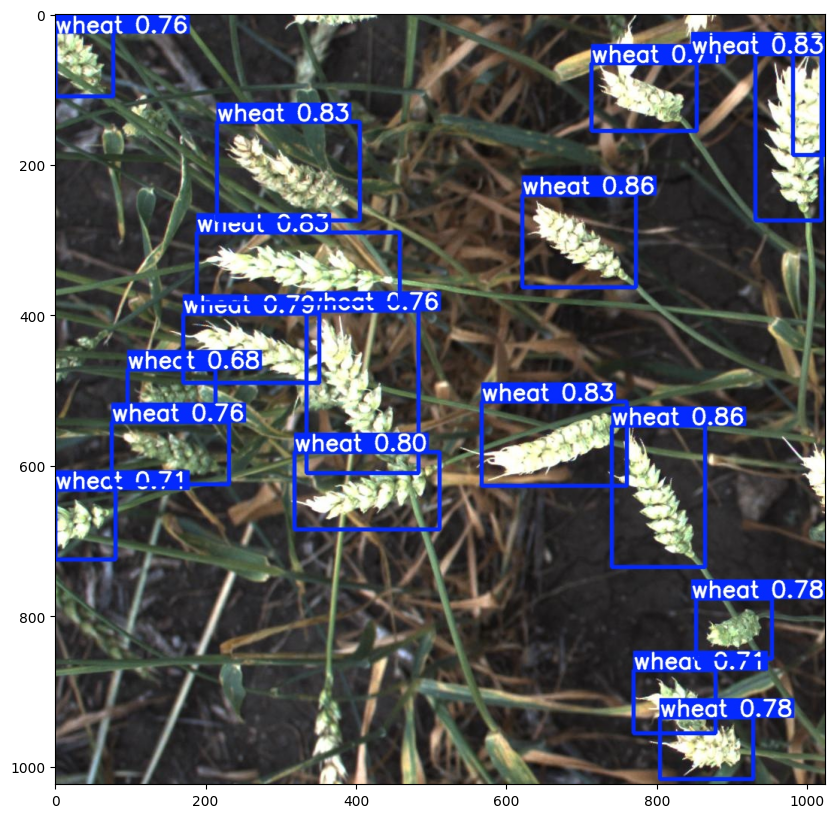

In [24]:
results = model.predict(source='/kaggle/working/wheat/images/val', save=True, conf=0.5, imgsz=1024)

# 예측된 이미지 중 하나 출력 (YOLO는 'runs/detect/predict' 폴더에 저장함)
import matplotlib.pyplot as plt
import cv2

# 가장 최근에 저장된 예측 이미지 보기
sample_res = '/kaggle/working/runs/detect/predict/005b0d8bb.jpg' # 실제 생성된 파일명으로 확인 필요
if os.path.exists(sample_res):
    img = cv2.imread(sample_res)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.show()